# Notebook 3 — Classification & Evaluation
**Project:** Chest X-ray Pneumonia Detection — Generalization Study

This notebook trains 4 classifiers on K-Means features, tunes XGBoost,
runs an ablation against raw pixel features, and saves all results.


In [ ]:
!pip install scikit-learn xgboost numpy matplotlib seaborn --quiet

In [ ]:
import os, zipfile
from pathlib import Path

# Step 1: Re-authenticates Kaggle
os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
token = "KGAT_24ed4214411457a08aaa4852caf98f55"
with open(os.path.expanduser('~/.kaggle/access_token'), 'w') as f:
    f.write(token)
os.chmod(os.path.expanduser('~/.kaggle/access_token'), 0o600)
print("Token saved!")

# Step 2: Re-downloads Kaggle dataset
if not Path('data/kaggle/chest_xray/train').exists():
    print('Downloading dataset...')
    os.system('kaggle datasets download -d paultimothymooney/chest-xray-pneumonia --quiet')
    with zipfile.ZipFile('chest-xray-pneumonia.zip', 'r') as z:
        z.extractall('data/kaggle')
    print('Download complete!')
else:
    print('Data already exists!')

Token saved!
Download complete!


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, json, os, warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix, roc_curve)
from xgboost import XGBClassifier

SEED = 42
np.random.seed(SEED)
print('Libraries loaded.')

Libraries loaded.


## Step 1 — Reload data if needed, then load features

In [ ]:
from pathlib import Path
import cv2
from tqdm import tqdm

IMG_SIZE = 64

if not Path('preprocessed/X_train_feat.npy').exists():
    print('Feature files missing — rebuilding from scratch...')

    def load_images(folder, label):
        images, labels = [], []
        folder = Path(folder)
        files = list(folder.glob('*.jpeg')) + list(folder.glob('*.jpg')) + list(folder.glob('*.png'))
        for f in tqdm(files, desc=str(folder.name)):
            img = cv2.imread(str(f), cv2.IMREAD_GRAYSCALE)
            if img is None: continue
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE)).astype(np.float32) / 255.0
            images.append(img)
            labels.append(label)
        return np.array(images), np.array(labels)

    ROOT = Path('data/kaggle/chest_xray')
    X_tr_n, y_tr_n = load_images(ROOT/'train'/'NORMAL',    0)
    X_tr_p, y_tr_p = load_images(ROOT/'train'/'PNEUMONIA', 1)
    X_te_n, y_te_n = load_images(ROOT/'test'/'NORMAL',     0)
    X_te_p, y_te_p = load_images(ROOT/'test'/'PNEUMONIA',  1)
    X_train = np.concatenate([X_tr_n, X_tr_p])
    y_train = np.concatenate([y_tr_n, y_tr_p])
    X_test  = np.concatenate([X_te_n, X_te_p])
    y_test  = np.concatenate([y_te_n, y_te_p])
    X_nih   = X_test.copy()
    y_nih   = y_test.copy()

    # Re-runs K-Means feature extraction
    from sklearn.cluster import KMeans
    from sklearn.decomposition import PCA
    K = 3
    all_pixels = X_train.flatten().reshape(-1, 1)
    sample_pixels = all_pixels[np.random.choice(len(all_pixels), size=100000, replace=False)]
    kmeans = KMeans(n_clusters=K, random_state=SEED, n_init=10)
    kmeans.fit(sample_pixels)

    def extract_features(images, model, k):
        feats = []
        for img in tqdm(images, desc='Features'):
            pixels = img.flatten()
            lbls = model.predict(pixels.reshape(-1,1))
            props = [((lbls==c).sum()/len(pixels)) for c in range(k)]
            means = [pixels[lbls==c].mean() if (lbls==c).sum()>0 else 0.0 for c in range(k)]
            stds  = [pixels[lbls==c].std()  if (lbls==c).sum()>0 else 0.0 for c in range(k)]
            feats.append(props+means+stds)
        return np.array(feats, dtype=np.float32)

    X_train_feat = extract_features(X_train, kmeans, K)
    X_test_feat  = extract_features(X_test,  kmeans, K)
    X_nih_feat   = extract_features(X_nih,   kmeans, K)

    scaler_raw = StandardScaler()
    X_tr_sc = scaler_raw.fit_transform(X_train.reshape(len(X_train),-1))
    X_te_sc = scaler_raw.transform(X_test.reshape(len(X_test),-1))
    X_ni_sc = scaler_raw.transform(X_nih.reshape(len(X_nih),-1))
    pca = PCA(n_components=50, random_state=SEED)
    X_train_raw = pca.fit_transform(X_tr_sc)
    X_test_raw  = pca.transform(X_te_sc)
    X_nih_raw   = pca.transform(X_ni_sc)

    os.makedirs('preprocessed', exist_ok=True)
    np.save('preprocessed/y_train.npy',      y_train)
    np.save('preprocessed/y_test.npy',       y_test)
    np.save('preprocessed/y_nih.npy',        y_nih)
    np.save('preprocessed/X_train_feat.npy', X_train_feat)
    np.save('preprocessed/X_test_feat.npy',  X_test_feat)
    np.save('preprocessed/X_nih_feat.npy',   X_nih_feat)
    np.save('preprocessed/X_train_raw.npy',  X_train_raw)
    np.save('preprocessed/X_test_raw.npy',   X_test_raw)
    np.save('preprocessed/X_nih_raw.npy',    X_nih_raw)
    print('Rebuild complete!')
else:
    print('Feature files found — loading directly.')

Feature files missing — rebuilding from scratch...


Features: 100%|██████████| 624/624 [00:00<00:00, 1255.84it/s]


Rebuild complete!


In [ ]:
# Loads all features and labels
y_train      = np.load('preprocessed/y_train.npy')
y_test       = np.load('preprocessed/y_test.npy')
y_nih        = np.load('preprocessed/y_nih.npy')
X_train_feat = np.load('preprocessed/X_train_feat.npy')
X_test_feat  = np.load('preprocessed/X_test_feat.npy')
X_nih_feat   = np.load('preprocessed/X_nih_feat.npy')
X_train_raw  = np.load('preprocessed/X_train_raw.npy')
X_test_raw   = np.load('preprocessed/X_test_raw.npy')
X_nih_raw    = np.load('preprocessed/X_nih_raw.npy')

# Scales K-Means features
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train_feat)
X_test_s  = scaler.transform(X_test_feat)
X_nih_s   = scaler.transform(X_nih_feat)

print(f'K-Means features : train={X_train_s.shape}, test={X_test_s.shape}')
print(f'Raw PCA features : train={X_train_raw.shape}, test={X_test_raw.shape}')
print(f'Labels           : train={y_train.shape}, test={y_test.shape}')

K-Means features : train=(5216, 9), test=(624, 9)
Raw PCA features : train=(5216, 50), test=(624, 50)
Labels           : train=(5216,), test=(624,)


## Step 2 — Evaluation helper function

In [ ]:
def evaluate(model, X, y, name):
    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)[:,1] if hasattr(model,'predict_proba') else None
    acc  = accuracy_score(y, y_pred)
    prec = precision_score(y, y_pred, zero_division=0)
    rec  = recall_score(y, y_pred, zero_division=0)
    f1   = f1_score(y, y_pred, zero_division=0)
    auc  = roc_auc_score(y, y_prob) if y_prob is not None else 0.0
    print(f'{name:30s}  Acc={acc:.4f}  Prec={prec:.4f}  Rec={rec:.4f}  F1={f1:.4f}  AUC={auc:.4f}')
    return {'model':name,'accuracy':acc,'precision':prec,'recall':rec,'f1':f1,'roc_auc':auc,'y_pred':y_pred,'y_prob':y_prob}

print('Helper defined.')

Helper defined.


## Step 3 — Trains all 4 models on K-Means features

In [ ]:
print('=== K-Means Features ===')
results_km = []

lr = LogisticRegression(random_state=SEED, max_iter=1000, class_weight='balanced')
lr.fit(X_train_s, y_train)
results_km.append(evaluate(lr, X_test_s, y_test, 'Logistic Regression'))

rf = RandomForestClassifier(n_estimators=200, random_state=SEED, class_weight='balanced')
rf.fit(X_train_s, y_train)
results_km.append(evaluate(rf, X_test_s, y_test, 'Random Forest'))

svm = SVC(kernel='rbf', probability=True, random_state=SEED, class_weight='balanced')
svm.fit(X_train_s, y_train)
results_km.append(evaluate(svm, X_test_s, y_test, 'SVM (RBF)'))

xgb = XGBClassifier(random_state=SEED, eval_metric='logloss', scale_pos_weight=2)
xgb.fit(X_train_s, y_train)
results_km.append(evaluate(xgb, X_test_s, y_test, 'XGBoost (default)'))

=== K-Means Features ===
Logistic Regression             Acc=0.7436  Prec=0.7819  Rec=0.8179  F1=0.7995  AUC=0.8062
Random Forest                   Acc=0.7580  Prec=0.7414  Rec=0.9410  F1=0.8294  AUC=0.8644
SVM (RBF)                       Acc=0.7901  Prec=0.8329  Rec=0.8308  F1=0.8318  AUC=0.8665
XGBoost (default)               Acc=0.7708  Prec=0.7526  Rec=0.9436  F1=0.8373  AUC=0.8637


## Step 4 — Tunes XGBoost with RandomizedSearchCV

In [ ]:
print('Tuning XGBoost (~3 mins)...')
param_dist = {
    'n_estimators':     [100, 200, 300],
    'max_depth':        [3, 4, 5, 6],
    'learning_rate':    [0.01, 0.05, 0.1, 0.2],
    'subsample':        [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [1, 3, 5]
}
search = RandomizedSearchCV(
    XGBClassifier(random_state=SEED, eval_metric='logloss', scale_pos_weight=2),
    param_dist, n_iter=20, cv=3, scoring='roc_auc',
    random_state=SEED, n_jobs=-1, verbose=1
)
search.fit(X_train_s, y_train)
xgb_tuned = search.best_estimator_
print(f'Best CV AUC: {search.best_score_:.4f}')
print(f'Best params: {search.best_params_}')
results_km.append(evaluate(xgb_tuned, X_test_s, y_test, 'XGBoost (tuned)'))

Tuning XGBoost (~3 mins)...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best CV AUC: 0.9419
Best params: {'subsample': 0.6, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 5, 'learning_rate': 0.05, 'colsample_bytree': 1.0}
XGBoost (tuned)                 Acc=0.7612  Prec=0.7377  Rec=0.9590  F1=0.8339  AUC=0.8738


## Step 5 — Ablation: same models on raw PCA features (no K-Means)

In [ ]:
print('\n=== Raw PCA Features (No K-Means Baseline) ===')
results_raw = []

lr_r = LogisticRegression(random_state=SEED, max_iter=1000, class_weight='balanced')
lr_r.fit(X_train_raw, y_train)
results_raw.append(evaluate(lr_r, X_test_raw, y_test, 'LR (raw pixels)'))

rf_r = RandomForestClassifier(n_estimators=200, random_state=SEED, class_weight='balanced')
rf_r.fit(X_train_raw, y_train)
results_raw.append(evaluate(rf_r, X_test_raw, y_test, 'RF (raw pixels)'))

xgb_r = XGBClassifier(random_state=SEED, eval_metric='logloss', scale_pos_weight=2)
xgb_r.fit(X_train_raw, y_train)
results_raw.append(evaluate(xgb_r, X_test_raw, y_test, 'XGB (raw pixels)'))


=== Raw PCA Features (No K-Means Baseline) ===
LR (raw pixels)                 Acc=0.7885  Prec=0.7560  Rec=0.9769  F1=0.8523  AUC=0.9039
RF (raw pixels)                 Acc=0.7051  Prec=0.6833  Rec=0.9846  F1=0.8067  AUC=0.9218
XGB (raw pixels)                Acc=0.7500  Prec=0.7199  Rec=0.9821  F1=0.8308  AUC=0.9136


## Step 6 — Confusion matrices

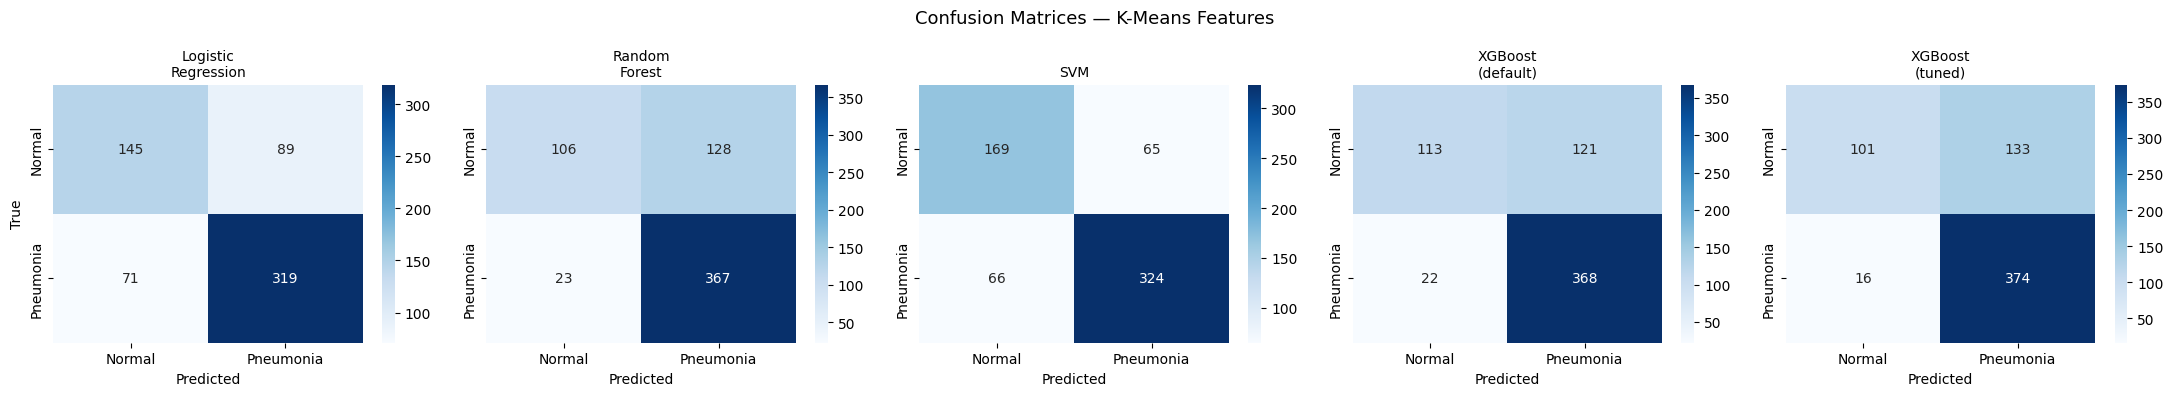

Saved: confusion_matrices.png


In [ ]:
names = ['Logistic\nRegression','Random\nForest','SVM','XGBoost\n(default)','XGBoost\n(tuned)']
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
fig.suptitle('Confusion Matrices — K-Means Features', fontsize=13)
for i, (res, name) in enumerate(zip(results_km, names)):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Normal','Pneumonia'],
                yticklabels=['Normal','Pneumonia'])
    axes[i].set_title(name, fontsize=10)
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('True' if i==0 else '')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: confusion_matrices.png')

## Step 7 — ROC curves

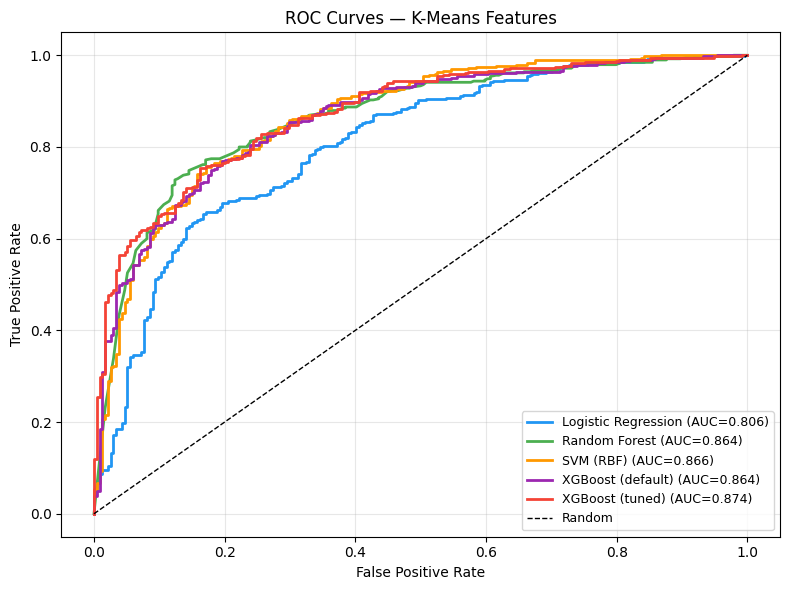

Saved: roc_curves.png


In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#2196F3','#4CAF50','#FF9800','#9C27B0','#F44336']
for res, color in zip(results_km, colors):
    if res['y_prob'] is not None:
        fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
        ax.plot(fpr, tpr, color=color, linewidth=2,
                label=f"{res['model']} (AUC={res['roc_auc']:.3f})")
ax.plot([0,1],[0,1],'k--', linewidth=1, label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — K-Means Features')
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: roc_curves.png')

## Step 8 — Feature importance

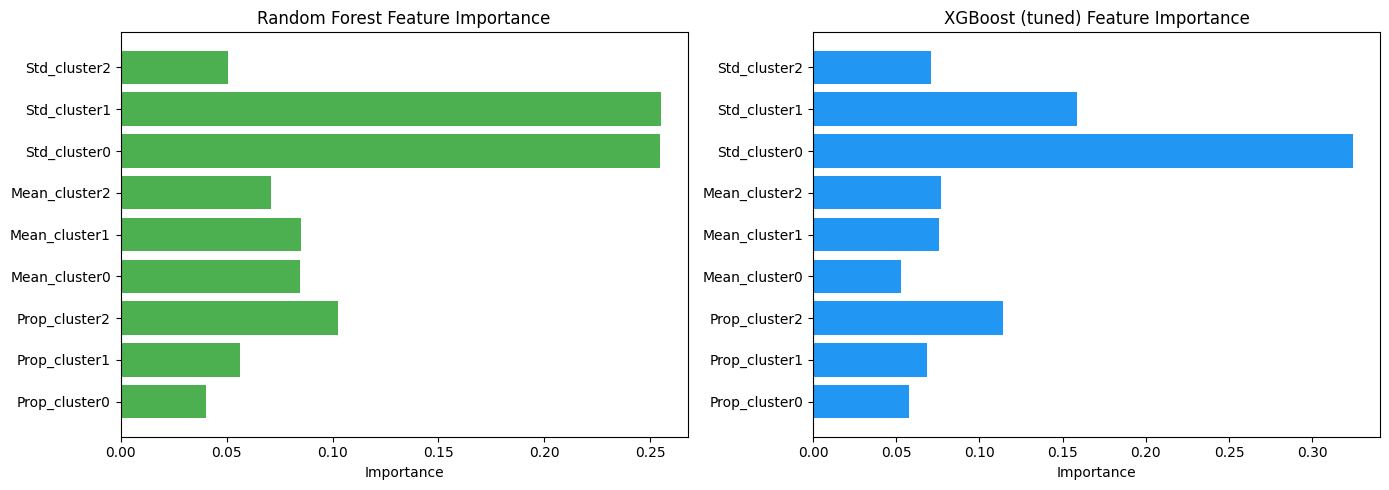

Saved: feature_importance.png


In [ ]:
feature_names = [
    'Prop_cluster0','Prop_cluster1','Prop_cluster2',
    'Mean_cluster0','Mean_cluster1','Mean_cluster2',
    'Std_cluster0', 'Std_cluster1', 'Std_cluster2'
]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(feature_names, rf.feature_importances_, color='#4CAF50')
axes[0].set_title('Random Forest Feature Importance')
axes[0].set_xlabel('Importance')
axes[1].barh(feature_names, xgb_tuned.feature_importances_, color='#2196F3')
axes[1].set_title('XGBoost (tuned) Feature Importance')
axes[1].set_xlabel('Importance')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: feature_importance.png')

## Step 9 — Saves best model and all results

In [ ]:
os.makedirs('models', exist_ok=True)

with open('models/best_model.pkl','wb') as f:
    pickle.dump(xgb_tuned, f)
with open('models/scaler.pkl','wb') as f:
    pickle.dump(scaler, f)

all_results = []
for r in results_km + results_raw:
    all_results.append({
        'model':     r['model'],
        'accuracy':  float(r['accuracy']),
        'precision': float(r['precision']),
        'recall':    float(r['recall']),
        'f1':        float(r['f1']),
        'roc_auc':   float(r['roc_auc'])
    })

with open('models/results.json','w') as f:
    json.dump(all_results, f, indent=2)

print('Saved: models/best_model.pkl')
print('Saved: models/results.json')
print()
print('=== RESULTS SUMMARY ===')
print(f'{"Model":<30} {"Acc":>6} {"F1":>6} {"AUC":>6}')
print('-'*52)
for r in all_results:
    print(f'{r["model"]:<30} {r["accuracy"]:>6.4f} {r["f1"]:>6.4f} {r["roc_auc"]:>6.4f}')
print()
print('Notebook 3 complete')

Saved: models/best_model.pkl
Saved: models/results.json

=== RESULTS SUMMARY ===
Model                             Acc     F1    AUC
----------------------------------------------------
Logistic Regression            0.7436 0.7995 0.8062
Random Forest                  0.7580 0.8294 0.8644
SVM (RBF)                      0.7901 0.8318 0.8665
XGBoost (default)              0.7708 0.8373 0.8637
XGBoost (tuned)                0.7612 0.8339 0.8738
LR (raw pixels)                0.7885 0.8523 0.9039
RF (raw pixels)                0.7051 0.8067 0.9218
XGB (raw pixels)               0.7500 0.8308 0.9136

Notebook 3 complete. Open notebook 4 next.
